#Modern AI Pro: Regression techniques to predict home prices
We are going to use a simple dataset to learn linear regression. This is the foundation of machine learning. https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data

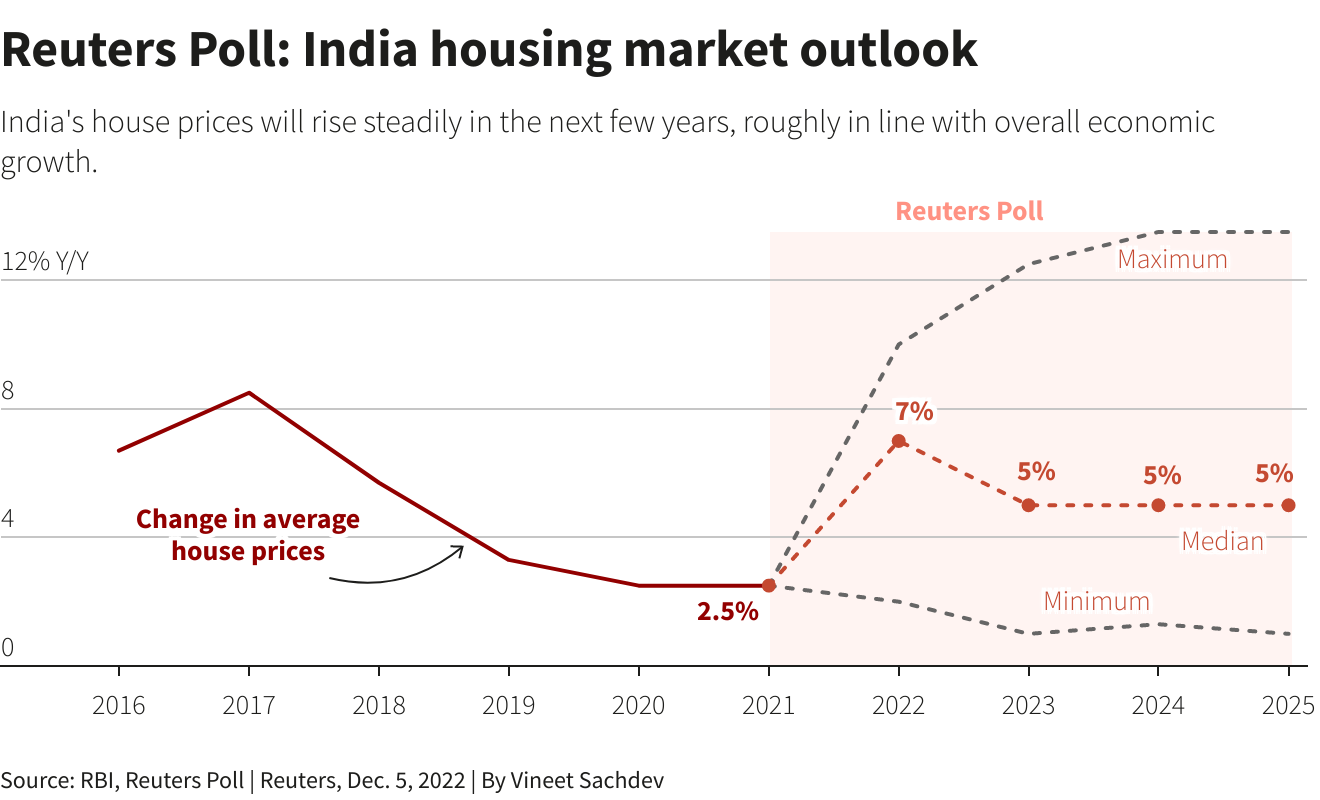

## Step 1: Download the data from Kaggle and load into the datafame

In [21]:
# from google.colab import userdata
# from os import environ

# environ["KAGGLE_KEY"]      = userdata.get('KAGGLE_KEY')
# environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')

# ! pip -q install kaggle
# ! kaggle competitions download -c house-prices-advanced-regression-techniques
# ! unzip /content/house-prices-advanced-regression-techniques.zip

In [22]:
import pandas as pd
df = pd.read_csv("train.csv")
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [23]:
df.columns.to_list()

['Id',
 'MSSubClass',
 'MSZoning',
 'LotFrontage',
 'LotArea',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'MasVnrArea',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinSF1',
 'BsmtFinType2',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'KitchenQual',
 'TotRmsAbvGrd',
 'Functional',
 'Fireplaces',
 'FireplaceQu',
 'GarageType',
 'GarageYrBlt',
 'GarageFinish',
 'GarageCars',
 'GarageArea',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'WoodDeckSF',
 'OpenPorchSF'

## Step 2: Visualize the data

In [24]:
from matplotlib import pyplot as plt
%matplotlib inline

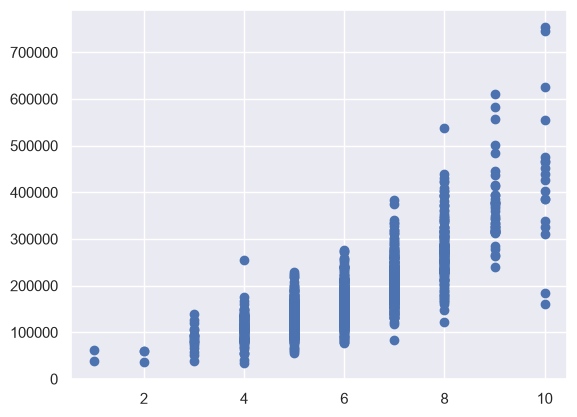

In [25]:
plt.scatter(df['OverallQual'],df['SalePrice'])

In [26]:
from sklearn.preprocessing import LabelEncoder

for col in df.columns:
  if pd.api.types.is_numeric_dtype(df[col].dtype):
    if df[col].isnull().any():
      df[col].fillna(df[col].median(),inplace=True)
  else:
    df[col] = LabelEncoder().fit_transform(df[col])

df

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10888\639993136.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].median(),inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10888\639993136.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment us

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,3,65.0,8450,1,2,3,3,0,...,0,3,4,4,0,2,2008,8,4,208500
1,2,20,3,80.0,9600,1,2,3,3,0,...,0,3,4,4,0,5,2007,8,4,181500
2,3,60,3,68.0,11250,1,2,0,3,0,...,0,3,4,4,0,9,2008,8,4,223500
3,4,70,3,60.0,9550,1,2,0,3,0,...,0,3,4,4,0,2,2006,8,0,140000
4,5,60,3,84.0,14260,1,2,0,3,0,...,0,3,4,4,0,12,2008,8,4,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,3,62.0,7917,1,2,3,3,0,...,0,3,4,4,0,8,2007,8,4,175000
1456,1457,20,3,85.0,13175,1,2,3,3,0,...,0,3,2,4,0,2,2010,8,4,210000
1457,1458,70,3,66.0,9042,1,2,3,3,0,...,0,3,0,2,2500,5,2010,8,4,266500
1458,1459,20,3,68.0,9717,1,2,3,3,0,...,0,3,4,4,0,4,2010,8,4,142125


<Axes: >

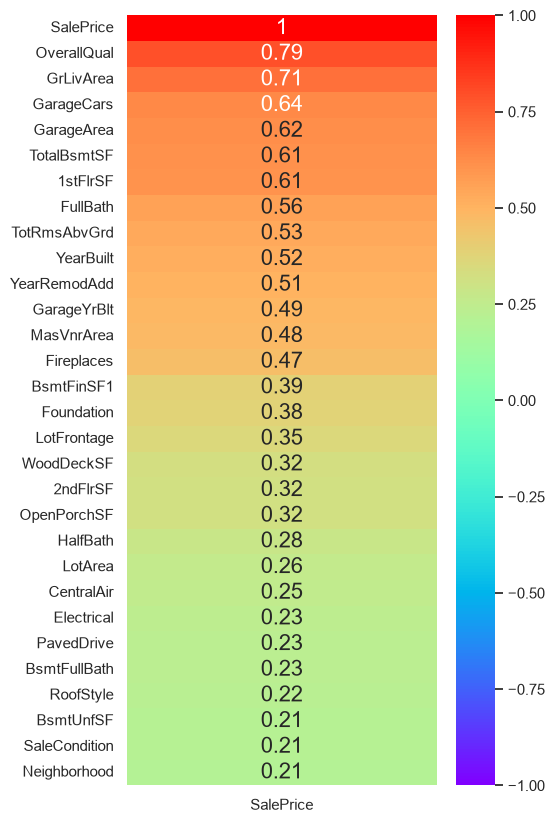

In [27]:
import seaborn as sns
sns.set()

top_features = df.corr()[['SalePrice']].sort_values(by=['SalePrice'],ascending=False).head(30)
plt.figure(figsize=(5,10))
sns.heatmap(top_features,cmap='rainbow', annot=True,annot_kws={"size": 16}, vmin=-1)


## Step 3: Setup the Machine Learning

In [28]:
y = df["SalePrice"]
X = df.drop("SalePrice",axis="columns")
X

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,3,65.0,8450,1,2,3,3,0,...,0,0,3,4,4,0,2,2008,8,4
1,2,20,3,80.0,9600,1,2,3,3,0,...,0,0,3,4,4,0,5,2007,8,4
2,3,60,3,68.0,11250,1,2,0,3,0,...,0,0,3,4,4,0,9,2008,8,4
3,4,70,3,60.0,9550,1,2,0,3,0,...,0,0,3,4,4,0,2,2006,8,0
4,5,60,3,84.0,14260,1,2,0,3,0,...,0,0,3,4,4,0,12,2008,8,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,3,62.0,7917,1,2,3,3,0,...,0,0,3,4,4,0,8,2007,8,4
1456,1457,20,3,85.0,13175,1,2,3,3,0,...,0,0,3,2,4,0,2,2010,8,4
1457,1458,70,3,66.0,9042,1,2,3,3,0,...,0,0,3,0,2,2500,5,2010,8,4
1458,1459,20,3,68.0,9717,1,2,3,3,0,...,0,0,3,4,4,0,4,2010,8,4


In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=10)
y_test

854     170000
381     187750
816     137000
577     164500
35      309000
         ...  
970     135000
598     217500
1058    335000
1018    160000
387     125000
Name: SalePrice, Length: 292, dtype: int64

In [30]:
X_test

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
854,855,20,3,102.0,17920,1,2,3,3,0,...,312,0,3,4,4,0,7,2006,8,0
381,382,20,1,60.0,7200,1,1,3,3,0,...,0,0,3,4,4,0,8,2006,6,5
816,817,20,3,NaN,11425,1,2,0,3,0,...,0,0,3,4,4,0,7,2006,8,4
577,578,80,3,96.0,11777,1,2,0,3,0,...,0,0,3,4,4,0,5,2006,8,0
35,36,60,3,108.0,13418,1,2,3,3,0,...,0,0,3,4,4,0,9,2006,8,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
970,971,50,3,60.0,10800,1,2,3,3,0,...,0,0,3,4,4,0,12,2006,8,0
598,599,20,3,80.0,12984,1,2,3,0,0,...,0,0,3,4,4,0,3,2006,8,4
1058,1059,60,3,96.0,11308,1,2,0,3,0,...,0,0,3,4,4,0,7,2009,8,4
1018,1019,80,3,NaN,10784,1,2,0,3,0,...,0,0,3,4,4,0,5,2007,8,4


In [31]:
h=X_train.isna().count()
print(h)

Id               1168
MSSubClass       1168
MSZoning         1168
LotFrontage      1168
LotArea          1168
                 ... 
MiscVal          1168
MoSold           1168
YrSold           1168
SaleType         1168
SaleCondition    1168
Length: 80, dtype: int64


In [32]:
from sklearn.linear_model import LinearRegression
# trainer = LinearRegression()
# trainer.fit(X_train,y_train)
# trainer.fit(X_train,y_train)


## Step 4: Score and Understand

In [33]:
trainer.score(X_test,y_test)

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
import pickle
with open('model_regression_HousingPricePrediction.pkl', 'wb') as file:
    pickle.dump(trainer, file)

In [ ]:
# Let's pick a random house and check the results
import random
my_choice = random.randrange(len(X_test))
print(my_choice)
print("Actual price: ", y_test.iloc[my_choice], "Predicted Price: ", trainer.predict(X_test.iloc[[my_choice]]))

41
Actual price:  114504 Predicted Price:  [114126.81705864]
